# Music Genres Clustering

- **Index**: Veri setindeki kayıt numarası, benzersiz kimlik  
- **Title**: Şarkının adı  
- **Artist**: Şarkının sanatçısı  
- **Top Genre**: Şarkının ait olduğu müzik türü  
- **Year**: Şarkının yayın yılı  
- **Beats Per Minute (BPM)**: Şarkının dakikadaki ritim sayısı  
- **Energy**: Şarkının enerjisini gösteren skor (yüksek enerji → hareketli)  
- **Danceability**: Şarkının dans edilebilirlik skoru (yüksek → kolay dans edilebilir)  
- **Loudness (dB)**: Şarkının ses yüksekliği desibel cinsinden  
- **Liveness**: Canlı performans hissi skoru (yüksek → canlı performans izlenimi)  
- **Valence**: Şarkının duygusal tonunu gösterir (yüksek → mutlu/pozitif, düşük → hüzünlü/negatif)  
- **Length (Duration)**: Şarkının süresi (dakika:saniye formatında)  
- **Acousticness**: Şarkının akustik olma derecesi (yüksek → daha akustik)  
- **Speechiness**: Şarkıda konuşma benzeri öğelerin yoğunluğu (yüksek → daha çok sözlü içerik)  
- **Popularity**: Şarkının popülerlik skoru (yüksek → daha popüler)  

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn import cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import linkage, dendrogram

from joblib import dump
from tensorflow.keras.models import load_model
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

In [2]:
df=pd.read_csv('Spotify-2000.csv')

### EDA - Exploratory Data Analysis

In [3]:
df.head()

,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256,1,3,59


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Index                   1994 non-null   int64 
 1   Title                   1994 non-null   object
 2   Artist                  1994 non-null   object
 3   Top Genre               1994 non-null   object
 4   Year                    1994 non-null   int64 
 5   Beats Per Minute (BPM)  1994 non-null   int64 
 6   Energy                  1994 non-null   int64 
 7   Danceability            1994 non-null   int64 
 8   Loudness (dB)           1994 non-null   int64 
 9   Liveness                1994 non-null   int64 
 10  Valence                 1994 non-null   int64 
 11  Length (Duration)       1994 non-null   object
 12  Acousticness            1994 non-null   int64 
 13  Speechiness             1994 non-null   int64 
 14  Popularity              1994 non-null   int64 
dtypes: i

In [5]:
df.shape

(1994, 15)

In [6]:
df.isnull().sum()

Index                     0
Title                     0
Artist                    0
Top Genre                 0
Year                      0
Beats Per Minute (BPM)    0
Energy                    0
Danceability              0
Loudness (dB)             0
Liveness                  0
Valence                   0
Length (Duration)         0
Acousticness              0
Speechiness               0
Popularity                0
dtype: int64

In [7]:
df.describe()

,Index,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Acousticness,Speechiness,Popularity
count,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.000000,1994.00000
mean,997.500000,1992.992979,120.215647,59.679539,53.238215,-9.008526,19.012036,49.408726,28.858074,4.994985,59.52658
std,575.762538,16.116048,28.028096,22.154322,15.351507,3.647876,16.727378,24.858212,29.011986,4.401566,14.35160
min,1.000000,1956.000000,37.000000,3.000000,10.000000,-27.000000,2.000000,3.000000,0.000000,2.000000,11.00000
25%,499.250000,1979.000000,99.000000,42.000000,43.000000,-11.000000,9.000000,29.000000,3.000000,3.000000,49.25000
50%,997.500000,1993.000000,119.000000,61.000000,53.000000,-8.000000,12.000000,47.000000,18.000000,4.000000,62.00000
75%,1495.750000,2007.000000,136.000000,78.000000,64.000000,-6.000000,23.000000,69.750000,50.000000,5.000000,71.00000
max,1994.000000,2019.000000,206.000000,100.000000,96.000000,-2.000000,99.000000,99.000000,99.000000,55.000000,100.00000


Text(0.5, 1.0, 'Top 10 Music Genres Distribution')

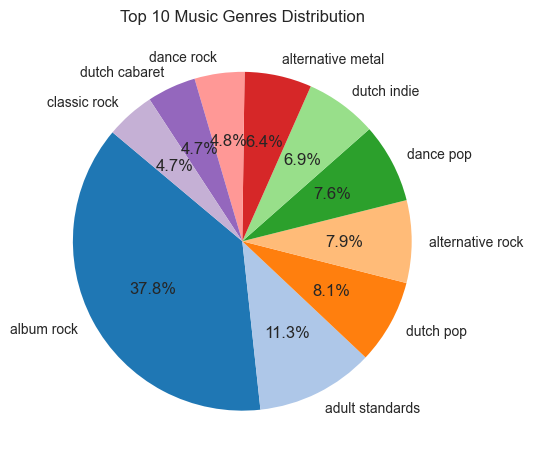

In [48]:
plt.subplot
genre_counts = df['Top Genre'].value_counts().head(10)  # En popüler 10 tür
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title('Top 10 Music Genres Distribution')

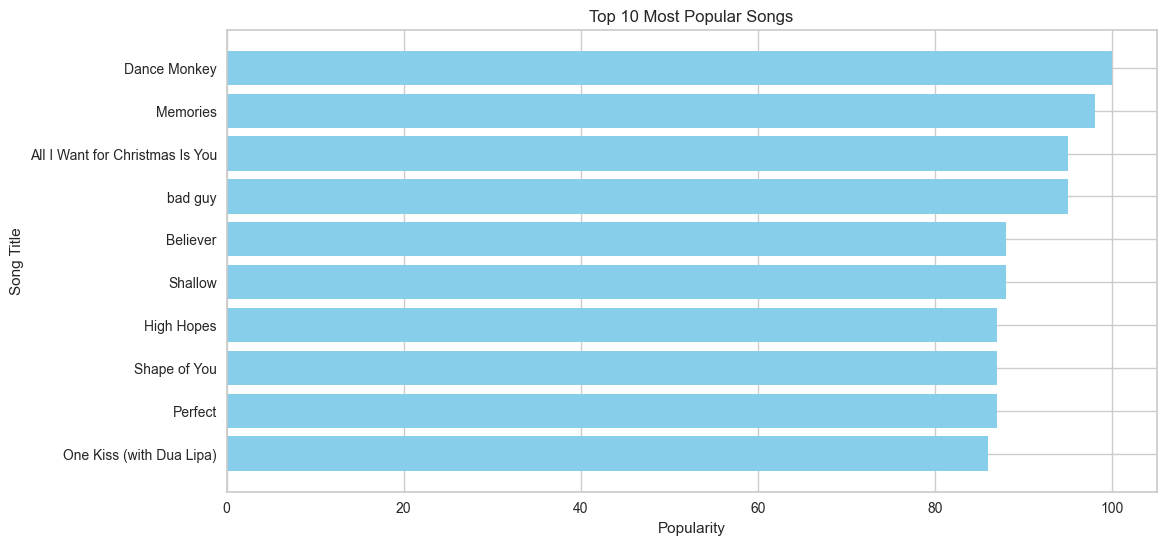

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Örnek veri: df adında veri seti olduğunu varsayıyoruz
# En popüler 10 şarkıyı seçiyoruz
top_songs = df.sort_values(by="Popularity", ascending=False).head(10)

# Grafik oluşturma
plt.figure(figsize=(12,6))
plt.barh(top_songs["Title"], top_songs["Popularity"], color="skyblue")
plt.xlabel("Popularity")
plt.ylabel("Song Title")
plt.title("Top 10 Most Popular Songs")
plt.gca().invert_yaxis()  # En popüler şarkı yukarıda olacak şekilde
plt.show()

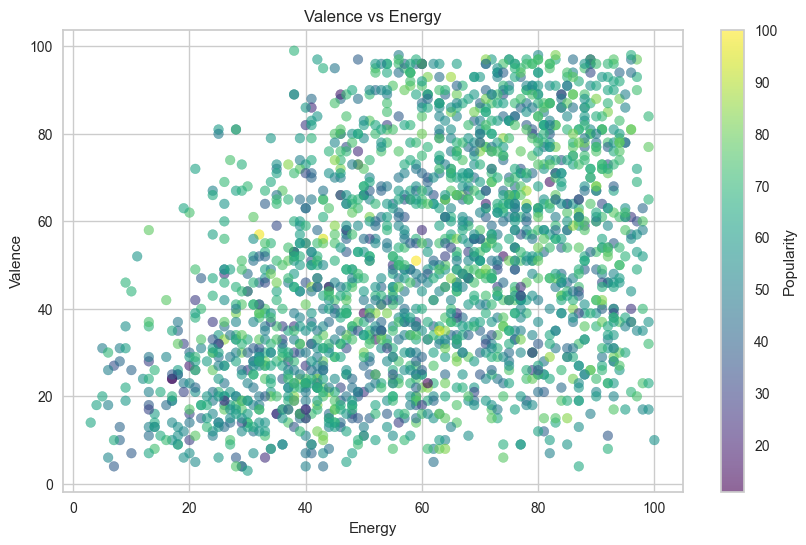

In [43]:
plt.figure(figsize=(10,6))
plt.scatter(df['Energy'], df['Valence'], alpha=0.6, c=df['Popularity'], cmap='viridis')
plt.colorbar(label='Popularity')
plt.title('Valence vs Energy')
plt.xlabel('Energy')
plt.ylabel('Valence')
plt.show()

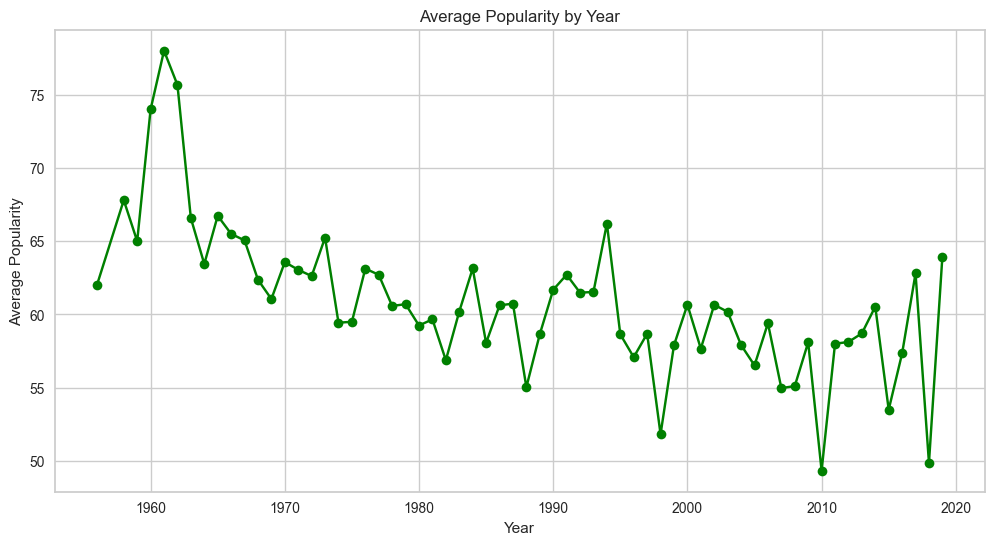

In [45]:
year_popularity = df.groupby('Year')['Popularity'].mean()

plt.figure(figsize=(12,6))
plt.plot(year_popularity.index, year_popularity.values, marker='o', color='green')
plt.title('Average Popularity by Year')
plt.xlabel('Year')
plt.ylabel('Average Popularity')
plt.grid(True)
plt.show()

In [8]:
df1=df[["Beats Per Minute (BPM)", "Loudness (dB)", "Liveness", "Valence", "Acousticness", "Speechiness"]]

In [9]:
df1.head()

,Beats Per Minute (BPM),Loudness (dB),Liveness,Valence,Acousticness,Speechiness
0,157,-14,11,68,94,3
1,135,-11,17,81,17,7
2,168,-9,7,52,2,17
3,173,-4,3,37,0,4
4,106,-5,10,87,1,3


In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Beats Per Minute (BPM)  1994 non-null   int64
 1   Loudness (dB)           1994 non-null   int64
 2   Liveness                1994 non-null   int64
 3   Valence                 1994 non-null   int64
 4   Acousticness            1994 non-null   int64
 5   Speechiness             1994 non-null   int64
dtypes: int64(6)
memory usage: 93.6 KB


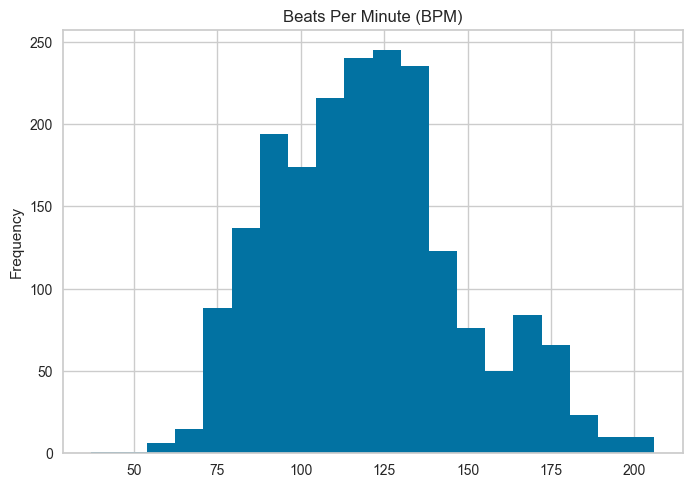

In [11]:
plt.figure()
df1["Beats Per Minute (BPM)"].plot.hist(bins=20)
plt.title("Beats Per Minute (BPM)")
plt.show()

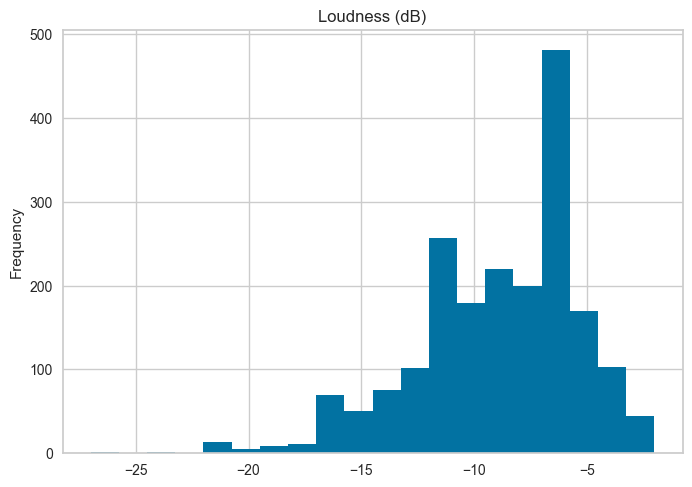

In [12]:
plt.figure()
df1["Loudness (dB)"].plot.hist(bins=20)
plt.title("Loudness (dB)")
plt.show()

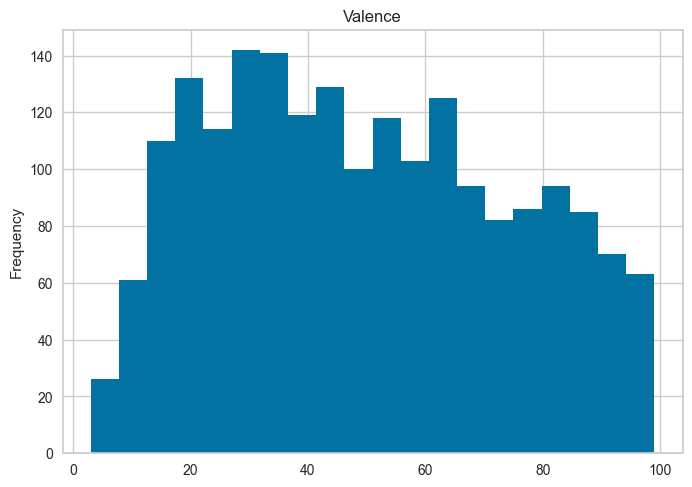

In [13]:
plt.figure()
df1["Valence"].plot.hist(bins=20)
plt.title("Valence")
plt.show()

### Model and Testing

In [14]:
model=KMeans(4)

In [15]:
model=model.fit(df1)

In [16]:
tahmin=model.predict(df1)

In [17]:
df1['cluster']=tahmin

In [18]:
df1.head()

,Beats Per Minute (BPM),Loudness (dB),Liveness,Valence,Acousticness,Speechiness,cluster
0,157,-14,11,68,94,3,2
1,135,-11,17,81,17,7,0
2,168,-9,7,52,2,17,3
3,173,-4,3,37,0,4,3
4,106,-5,10,87,1,3,0


In [19]:
silhouette_score(df1, tahmin)

0.24393537208996677

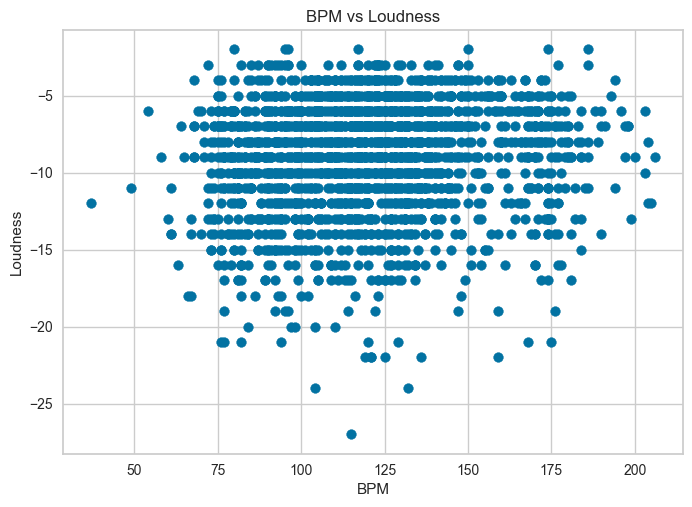

In [20]:
plt.figure()

plt.scatter(df1["Beats Per Minute (BPM)"], df1["Loudness (dB)"])

plt.xlabel("BPM")
plt.ylabel("Loudness")

plt.title("BPM vs Loudness")

plt.show()

In [21]:
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(df1)
    tahmin=model.predict(df1)
    ss1=silhouette_score(df1,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.2981799441115639
0.2606576310485798
0.25678795247685354
0.23920757644780383
0.2592080839647145
0.2578796906236285
0.26635461819603257
0.2595181510572388


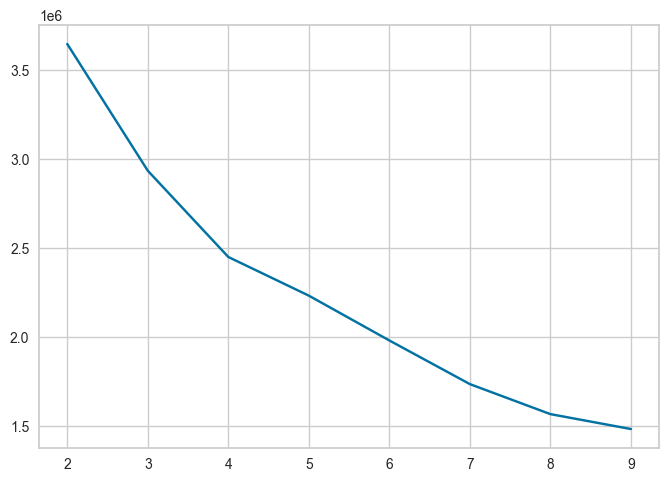

In [22]:
plt.plot(range(2,10),wcss)

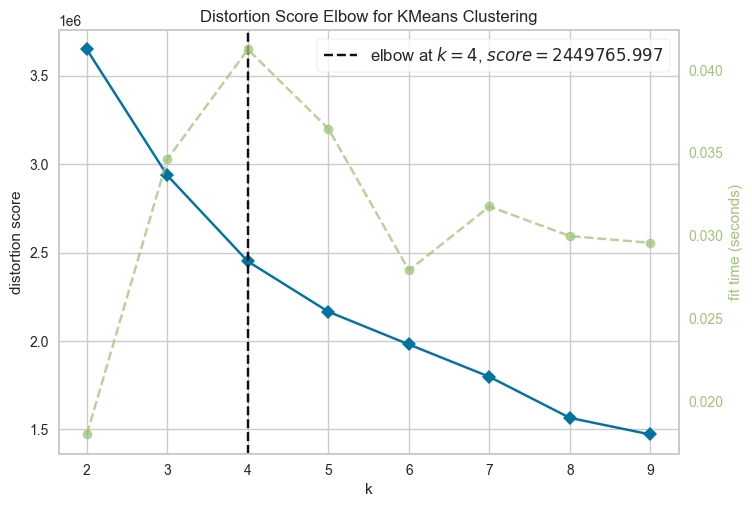

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [23]:
vis = KElbowVisualizer(KMeans(n_clusters=4, random_state=42), k=(2, 10), force_model=True)
vis.fit(df1)
vis.show()

In [24]:
model2=KMeans(4)

In [25]:
model2=model2.fit(df1)

In [26]:
tahmin2=model2.predict(df1)

In [27]:
silhouette_score(df1,tahmin2)

0.2566148012236296

In [28]:
dump(model2, 'musicgenres_clustering.joblib')

['musicgenres_clustering.joblib']

In [29]:
data=linkage(df1,method='ward',metric='euclidean')

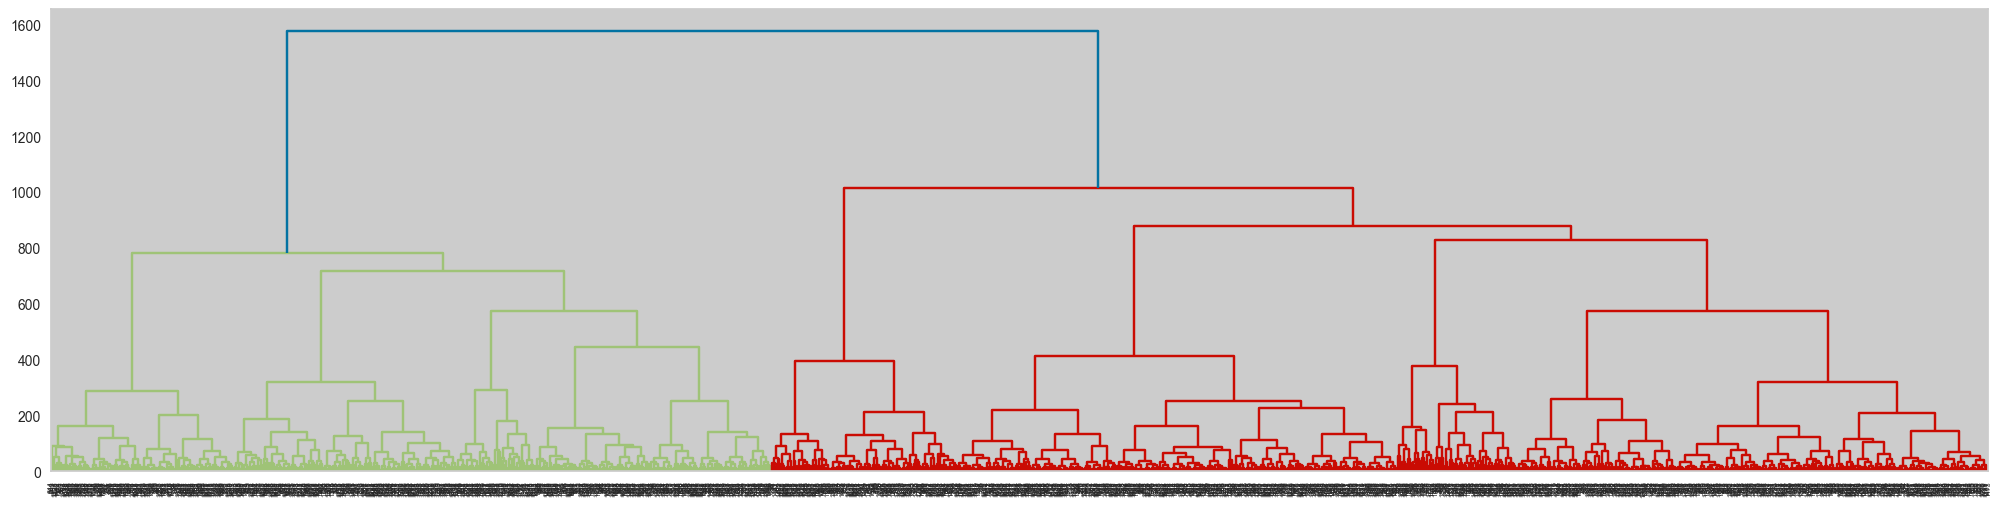

In [30]:
plt.figure(figsize=(25,6))
dendrogram(data);

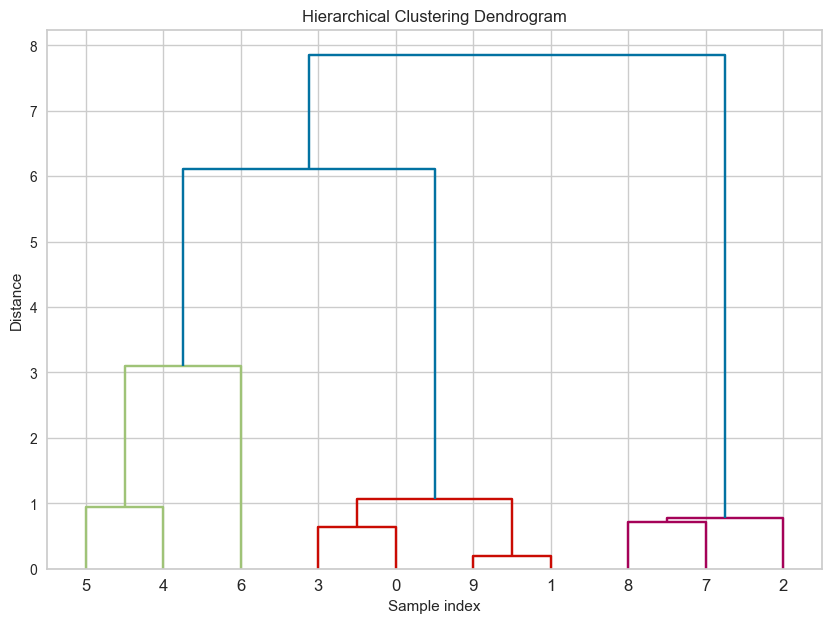

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate sample data
X, _ = make_blobs(n_samples=10, centers=3, cluster_std=0.60, random_state=0)

# Perform hierarchical clustering
linked = linkage(X, 'ward')

# Create a dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

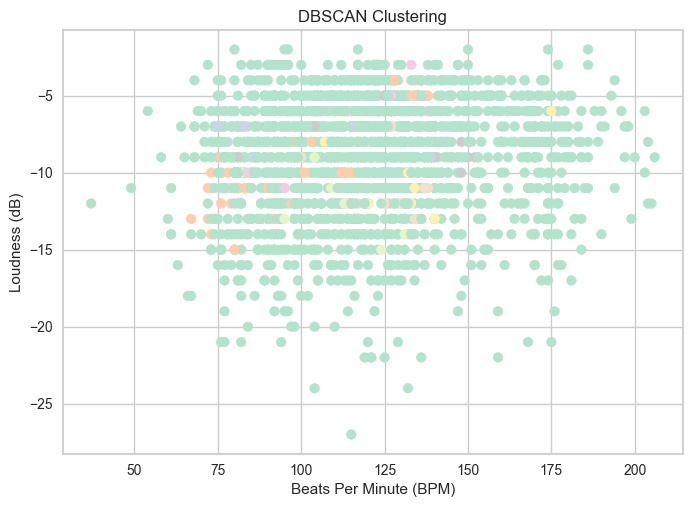

In [32]:
db=DBSCAN(min_samples=4)
from sklearn.preprocessing import StandardScaler
x2=StandardScaler().fit_transform(df1)
y=db.fit_predict(x2)
plt.title("DBSCAN Clustering")
plt.scatter(df1["Beats Per Minute (BPM)"], 
            df1["Loudness (dB)"], 
            c=y, cmap="Pastel2")
plt.xlabel("Beats Per Minute (BPM)")
plt.ylabel("Loudness (dB)")
plt.show()

### Deep Learning

In [33]:
scaler = StandardScaler()
df1_scaled = scaler.fit_transform(df1)

In [34]:
input_dim = df1_scaled.shape[1]  # input boyutu = 3
encoding_dim = 2                # gizli katmanda 2 boyut → görselleştirmek için

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)  # bottleneck layer

# Decoder
decoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

# Autoencoder
autoencoder = Model(inputs=input_layer, outputs=decoded)

# Sadece encoder modeli
encoder = Model(inputs=input_layer, outputs=encoded)

# Compile ve fit
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(df1_scaled, df1_scaled, epochs=50, batch_size=16, shuffle=True, verbose=1)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8916
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6569
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4715
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4304
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4044
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3838
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3700
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3562
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3433
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3347
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3262
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3182
Epoch 13/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3134
Epoch 14/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3065
Epoch 15/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [35]:
autoencoder.save('musicgenres_model.h5')

In [36]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df1)

In [37]:
df1_encoded = encoder.predict(df1_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


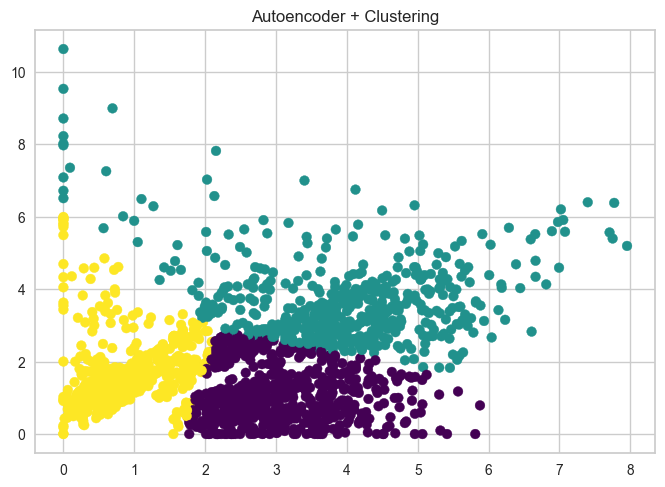

In [39]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(df1_encoded)

plt.figure()

plt.scatter(df1_encoded[:,0], df1_encoded[:,1], c=labels, cmap="viridis")

plt.title("Autoencoder + Clustering")
plt.show()